In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, recall_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import pandas as pd
import numpy as np

In [7]:
parquet_path = '../data/output/grid_conflict_climate_2019_23.parquet'

#Drop nas #
df = pd.read_parquet(parquet_path)
df = df.dropna()
df['target'] = (df['conflict_count'] >= 1).astype(int)
features = df.drop(['GEOID', 'conflict_count', 'target'], axis=1)
features = pd.get_dummies(features, columns=['year'], prefix='year')
X = features
y = df['target']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state = 42)),
    ('knn', KNeighborsClassifier(algorithm='brute'))
])

param_grid = [
    {
        'knn__n_neighbors': [3, 5, 7],
        'knn__weights': ['uniform', 'distance'],
        'knn__metric': ['euclidean']
    },
    {
        'knn__n_neighbors': [3, 5, 7],
        'knn__weights': ['uniform'],
        'knn__metric': ['cosine']
    }
]

grid_knn = GridSearchCV(pipeline, param_grid, cv=5, scoring='recall_weighted', n_jobs=1, verbose=1)
grid_knn.fit(X_train, y_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('smote', SMOTE(random_state=42)),
                                       ('knn',
                                        KNeighborsClassifier(algorithm='brute'))]),
             n_jobs=1,
             param_grid=[{'knn__metric': ['euclidean'],
                          'knn__n_neighbors': [3, 5, 7],
                          'knn__weights': ['uniform', 'distance']},
                         {'knn__metric': ['cosine'],
                          'knn__n_neighbors': [3, 5, 7],
                          'knn__weights': ['uniform']}],
             scoring='recall_weighted', verbose=1)

In [10]:
best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test)

In [11]:
print("\n--- Tuned KNN Model ---")
print(f"Best Parameters: {grid_knn.best_params_}")
print(f"\nTest Accuracy: {best_knn.score(X_test, y_test):.4f}")
print(f"Best Weighted Recall (CV): {grid_knn.best_score_:.4f}")
print("\nTest Recall (weighted):", recall_score(y_test, y_pred_knn, average='weighted'))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))


--- Tuned KNN Model ---
Best Parameters: {'knn__metric': 'cosine', 'knn__n_neighbors': 3, 'knn__weights': 'uniform'}

Test Accuracy: 0.8827
Best Weighted Recall (CV): 0.8822

Test Recall (weighted): 0.8826988093488167

Confusion Matrix:
[[5621  615]
 [ 183  384]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.90      0.93      6236
           1       0.38      0.68      0.49       567

    accuracy                           0.88      6803
   macro avg       0.68      0.79      0.71      6803
weighted avg       0.92      0.88      0.90      6803



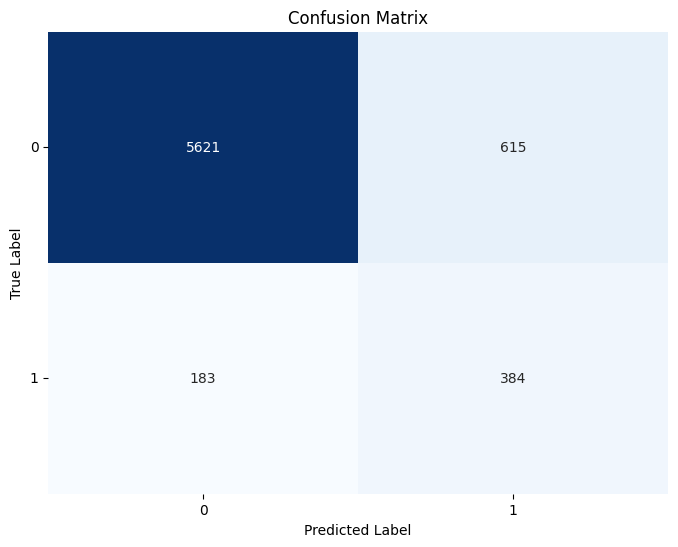

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Optional: use seaborn heatmap for custom styling 
labels = best_knn.classes_
conf_matrix = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(8, 6))
conf_df = pd.DataFrame(conf_matrix, index=labels, columns=labels)
sns.heatmap(conf_df, annot=True, fmt='d', cmap='Blues', cbar=False)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.show()